In [51]:
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [6]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [7]:
df =sns.load_dataset('tips')
df.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [9]:
# scatter  

상관관계 시각화 - 분포, 경향성, 이상치 탐색
- 희귀분석, 군집분석 등 탐색적 분석에 활용

<Axes: xlabel='total_bill', ylabel='tip'>

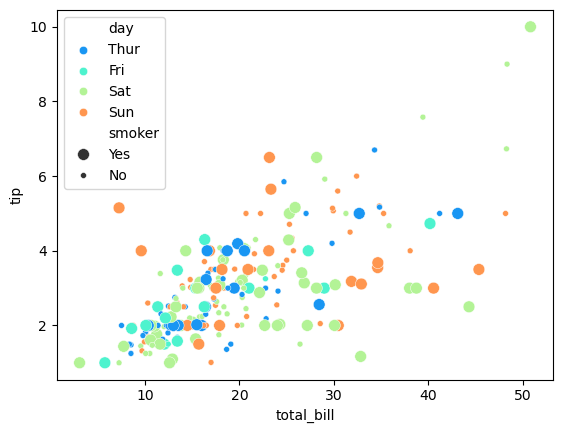

In [10]:
custom_palette = {'Female': 'yellow', 'Male': 'red'}
sns.scatterplot(x=df['total_bill'], y=df['tip'], hue=df['day'],
                size=df['smoker'], palette='rainbow')

In [11]:
df1 = pd.read_csv('./data/global_internet_users.csv')
df1.head(5)

,Unnamed: 0,Entity,Code,Year,Cellular Subscription,Internet Users(%),No. of Internet Users,Broadband Subscription
0,0,Afghanistan,AFG,1980,0.0,0.0,0,0.0
1,1,Afghanistan,AFG,1981,0.0,0.0,0,0.0
2,2,Afghanistan,AFG,1982,0.0,0.0,0,0.0
3,3,Afghanistan,AFG,1983,0.0,0.0,0,0.0
4,4,Afghanistan,AFG,1984,0.0,0.0,0,0.0


<Axes: xlabel='Year', ylabel='No. of Internet Users'>

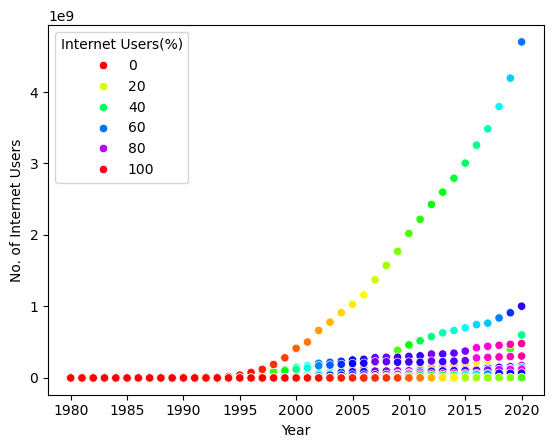

In [12]:
sns.scatterplot(x='Year', y='No. of Internet Users', data=df1, hue='Internet Users(%)', palette='hsv')

In [13]:
# 연도별 사용자 - 국가/지역 별로 구분해서 시각화
df1.Entity.unique()
entites = ['China', 'India', 'Finland']
df_country = df1.loc[df1['Entity'].isin(entites)]
df_country[:5]

,Unnamed: 0,Entity,Code,Year,Cellular Subscription,Internet Users(%),No. of Internet Users,Broadband Subscription
1579,1579,China,CHN,1980,0.0,0.0,0,0.0
1580,1580,China,CHN,1981,0.0,0.0,0,0.0
1581,1581,China,CHN,1982,0.0,0.0,0,0.0
1582,1582,China,CHN,1983,0.0,0.0,0,0.0
1583,1583,China,CHN,1984,0.0,0.0,0,0.0


<Axes: xlabel='Year', ylabel='No. of Internet Users'>

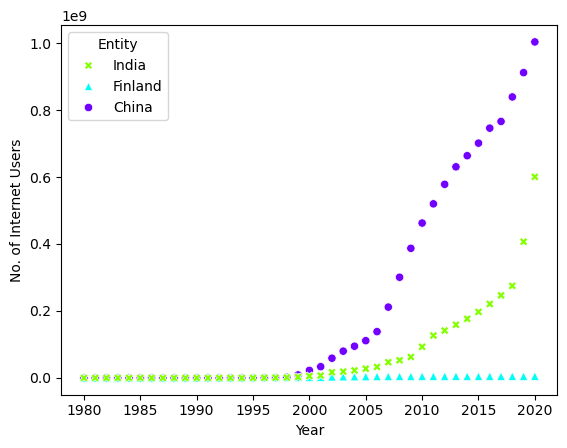

In [14]:
sns.scatterplot(x='Year', y='No. of Internet Users', data=df_country, hue='Entity', 
                hue_order=['India', 'Finland', 'China'] ,palette='hsv', markers=['o', '^', 'X'], style='Entity')

In [17]:
import plotly.express as px
fig = px.scatter(data_frame=df1, x='Year', y='No. of Internet Users', width=400, height=400)
fig.show()

In [ ]:
color = px.colors.qualitative.Light24
fig1 = px.scatter(data_frame=df_country, x='Year', y='No. of Internet Users', 
                  width=400, height=400, color='Entity', color_discrete_sequence=color,
                  symbol='Entity', # marker와 같은 기능
                  size='No. of Internet Users') 

fig1.show()


- 산점도는 데이터의 양에 따라 효과가 달라진다
- size 그룹간 차이 식별이 어려워질 수 있다
- 최대 2개정도 까지만 구별 - hue, style

# regplot - 산점도에 회귀 표시

<Axes: xlabel='total_bill', ylabel='tip'>

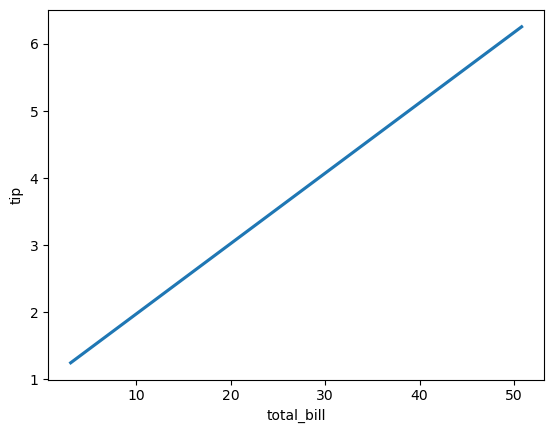

In [28]:
# 선 주변의 색칠된 영역은 오차구간 - ci 속성
sns.regplot(data=df, x='total_bill', y='tip',
            scatter=False, # scatter 안보이게
            ci =  None) 

<Axes: xlabel='size', ylabel='tip'>

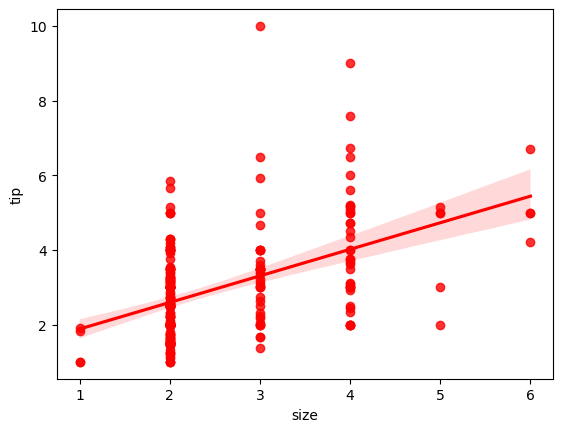

In [35]:
sns.regplot(data=df, x='size', y='tip', color='red') 

In [40]:
# plotly 에서 regplot
px.scatter(data_frame=df, x='total_bill', y='tip', trendline='ols',
           color='smoker') 

# Lineplot
x, y 점들을 이어주는 형식으로 데이터의 추세를 확인하는 용도로 활용합니다

C:\Users\Admin\AppData\Local\Temp\ipykernel_21548\621272146.py:1: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=('ci', 97)` for the same effect.




<Axes: xlabel='size', ylabel='tip'>

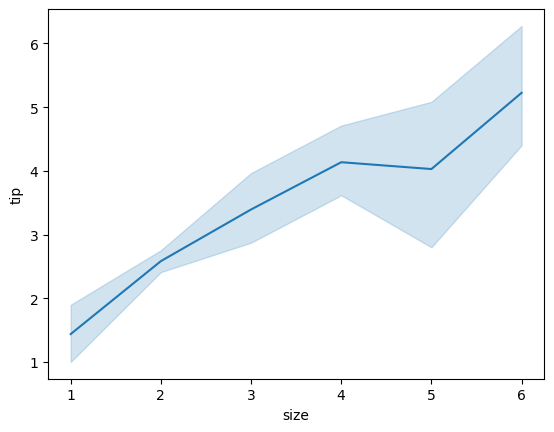

In [41]:
sns.lineplot(x='size', y='tip', data=df, ci=97)

C:\Users\Admin\AppData\Local\Temp\ipykernel_21548\4268789290.py:1: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=('ci', 97)` for the same effect.




<Axes: xlabel='Year', ylabel='No. of Internet Users'>

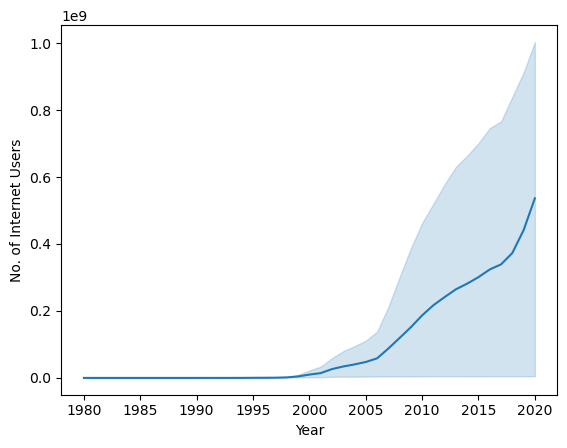

In [42]:
sns.lineplot(x='Year', y='No. of Internet Users', data=df_country, ci=97)

<Axes: xlabel='Year', ylabel='No. of Internet Users'>

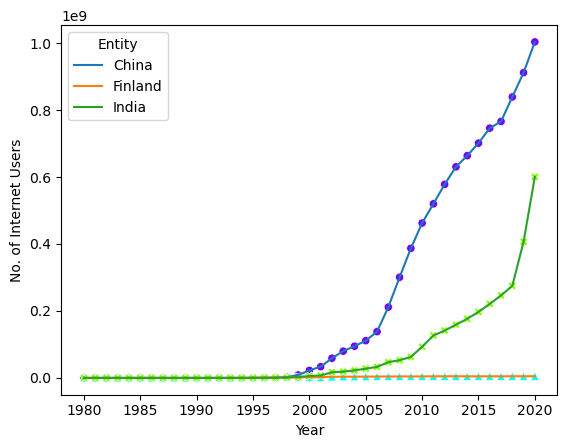

In [ ]:
sns.lineplot(x='Year', y='No. of Internet Users', data=df_country, hue='Entity')
sns.scatterplot(x='Year', y='No. of Internet Users', data=df_country,
                hue='Entity', hue_order=['India', 'Finland', 'China'] 
                ,palette='hsv', markers=['o', '^', 'X'], style='Entity',
                legend=False) # 엔티티 안보이게

In [45]:
px.line(
    data_frame=df_country, x='Year', y='No. of Internet Users',
    width=400, height=400, line_dash='Entity', color='Entity',
    symbol='Entity'
)

# boxplot
이상치 탐지, 통계량 확인, 분포확인

In [46]:
EV_df = pd.read_csv('./data/EV_charge.csv')
EV_df.head(3)

,sessionId,kwhTotal,dollars,created,ended,startTime,endTime,chargeTimeHrs,weekday,platform,...,managerVehicle,facilityType,Mon,Tues,Wed,Thurs,Fri,Sat,Sun,reportedZip
0,1366563,7.78,0.00,0014-11-18 15:40:26,0014-11-18 17:11:04,15,17,1.510556,Tue,android,...,0,3,0,1,0,0,0,0,0,0
1,3075723,9.74,0.00,0014-11-19 17:40:26,0014-11-19 19:51:04,17,19,2.177222,Wed,android,...,0,3,0,0,1,0,0,0,0,0
2,4228788,6.76,0.58,0014-11-21 12:05:46,0014-11-21 16:46:04,12,16,4.671667,Fri,android,...,0,3,0,0,0,0,1,0,0,0


C:\Users\Admin\AppData\Local\Temp\ipykernel_21548\3851730437.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='weekday', ylabel='kwhTotal'>

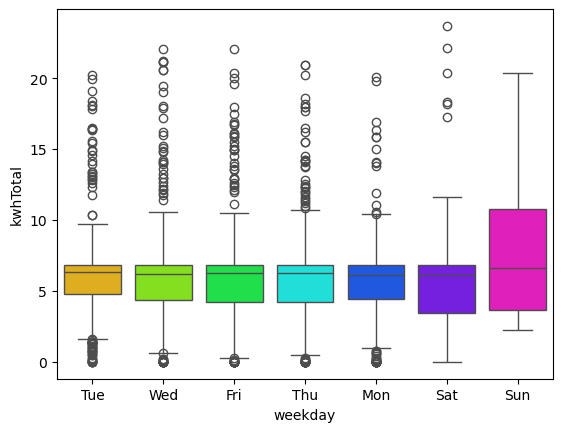

In [47]:
sns.boxplot(data=EV_df, x='weekday', y='kwhTotal', palette='hsv')

<Axes: xlabel='weekday', ylabel='kwhTotal'>

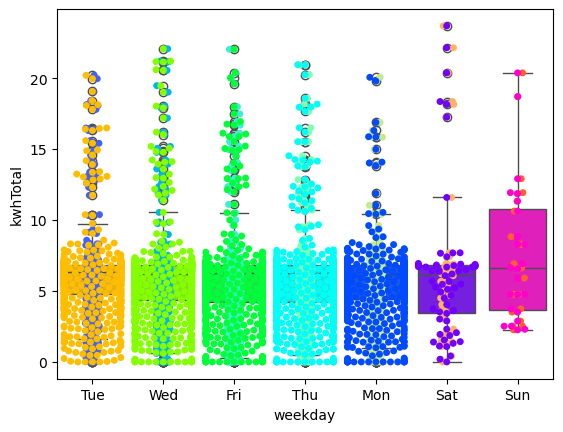

In [52]:
# 원본데이터 + 통계량을 같이 표현한다 > boxplot + stripplot 같이 사용
sns.boxplot(data=EV_df, x='weekday', y='kwhTotal', palette='hsv')
sns.stripplot(data=EV_df, x='weekday', y='kwhTotal', palette='rainbow')
sns.swarmplot(data=EV_df, x='weekday', y='kwhTotal', palette='hsv')

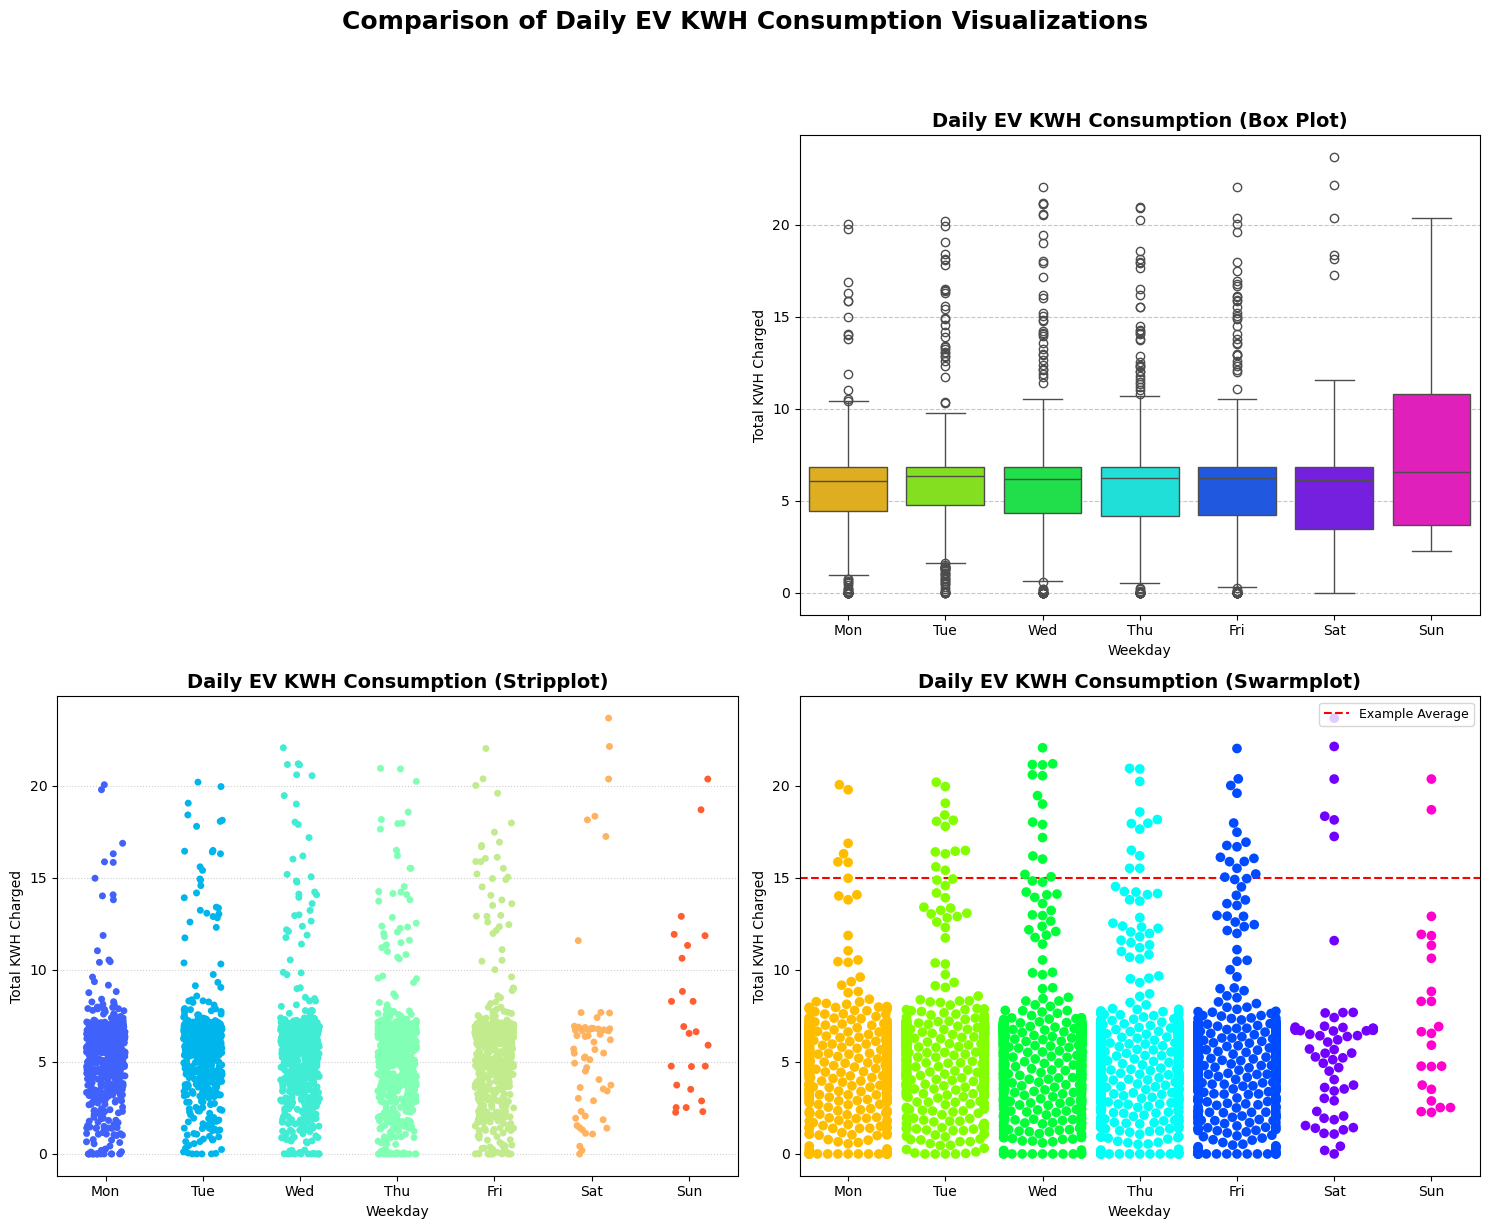

In [61]:
import matplotlib.pyplot as plt
# 요일 순서 지정 (범주형 데이터의 순서를 올바르게 정렬)
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
EV_df['weekday'] = pd.Categorical(EV_df['weekday'], categories=weekday_order, ordered=True)

# 전체 Figure와 Axes 객체 생성 (2행 2열, 첫 번째는 비워둠)
# figsize는 전체 그림의 크기를 결정합니다.
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))

# 사용하지 않을 첫 번째 서브플롯을 숨김 (레이아웃 조정을 위함)
fig.delaxes(axes[0, 0])

# 1. Boxplot (axes[0, 1] 위치에 그리기)
sns.boxplot(data=EV_df, x='weekday', y='kwhTotal', palette='hsv', ax=axes[0, 1])
axes[0, 1].set_title('Daily EV KWH Consumption (Box Plot)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Weekday', fontsize=10)
axes[0, 1].set_ylabel('Total KWH Charged', fontsize=10)
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)


# 2. Stripplot (axes[1, 0] 위치에 그리기)
sns.stripplot(data=EV_df, x='weekday', y='kwhTotal', palette='rainbow', jitter=0.2, ax=axes[1, 0])
axes[1, 0].set_title('Daily EV KWH Consumption (Stripplot)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Weekday', fontsize=10)
axes[1, 0].set_ylabel('Total KWH Charged', fontsize=10)
axes[1, 0].grid(axis='y', linestyle=':', alpha=0.6)


# 3. Swarmplot (axes[1, 1] 위치에 그리기)
sns.swarmplot(data=EV_df, x='weekday', y='kwhTotal', palette='hsv', size=7, ax=axes[1, 1])
axes[1, 1].set_title('Daily EV KWH Consumption (Swarmplot)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Weekday', fontsize=10)
axes[1, 1].set_ylabel('Total KWH Charged', fontsize=10)
axes[1, 1].axhline(y=15, color='red', linestyle='--', label='Example Average') # 수평선 추가
axes[1, 1].legend(loc='upper right', fontsize=9)


# 전체 Figure에 대한 제목 설정
fig.suptitle('Comparison of Daily EV KWH Consumption Visualizations', fontsize=18, fontweight='bold', y=1.02)

# 서브플롯 간 간격 자동 조정
plt.tight_layout(rect=[0, 0, 1, 0.98]) # suptitle이 잘리지 않도록 rect 조정

# 그래프 출력
plt.show()

In [ ]:
# boxplot 이 만능이 아니다
# swarmplot: 값이 겹치지 않는다 -> 분포를 잘 보여준다 성능저하 고려

<Axes: xlabel='weekday', ylabel='kwhTotal'>

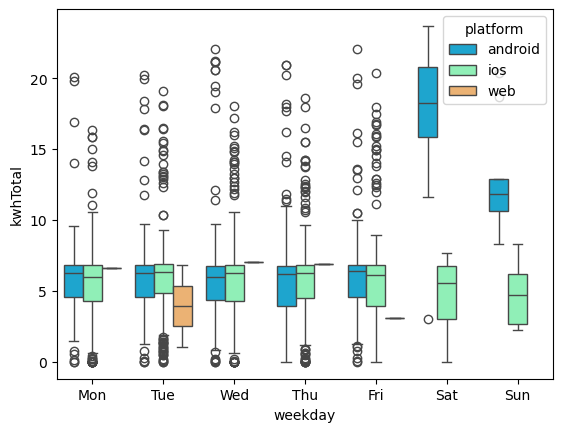

In [55]:
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.boxplot(data=EV_df, x='weekday', y='kwhTotal', palette='rainbow', hue= 'platform',order=weekday_order)

In [59]:
# plotly boxplot
px.box(
    data_frame=EV_df, x='weekday', y= 'kwhTotal',
    width=500, height=500,
    points= 'all', category_orders={'weekday': weekday_order}
    # 순서는 x축의 키를 입력해야함
    , color= 'platform'
)

# 바이올린 플롯
- 박스플롯 + 전체 분포모양 density 확인
- 중앙값 + 어디에 많이 몰려있나, 피크가 어디인가?

<Axes: xlabel='size', ylabel='tip'>

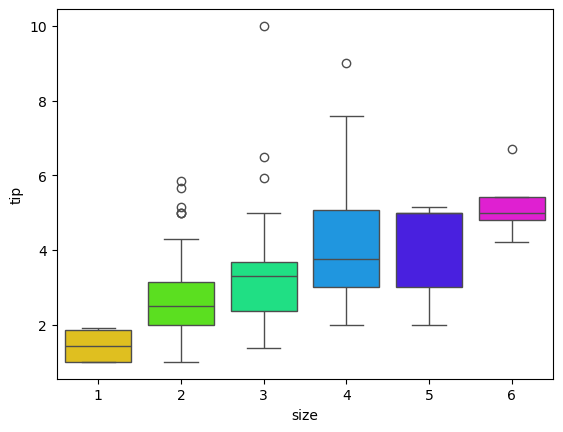

In [63]:
sns.boxplot(x='size', y='tip', data=df, palette='hsv')

<Axes: xlabel='size', ylabel='tip'>

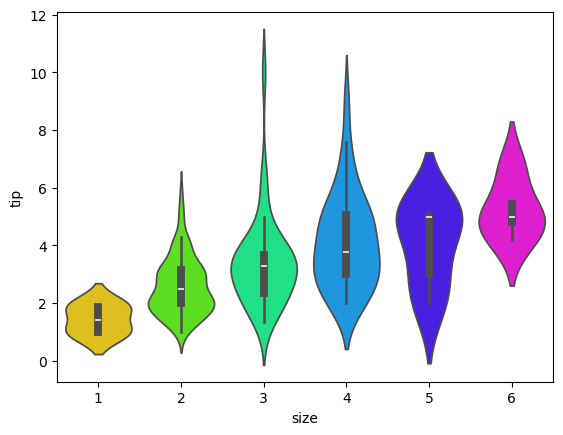

In [64]:
sns.violinplot(x='size', y='tip', data=df, palette='hsv')

# barplot

- 직선으로 오차구간: 에러바 클수록 변동성이 크다
- 막대의 크기 차이가 크지 않다 > 거의 비슷하다, 평균의 차이가 유의미 하지않다
- 추가분석 필요 - 단일변수로는 설명력이 부족: 총액, 성별, 시간대 등

<Axes: xlabel='size', ylabel='tip'>

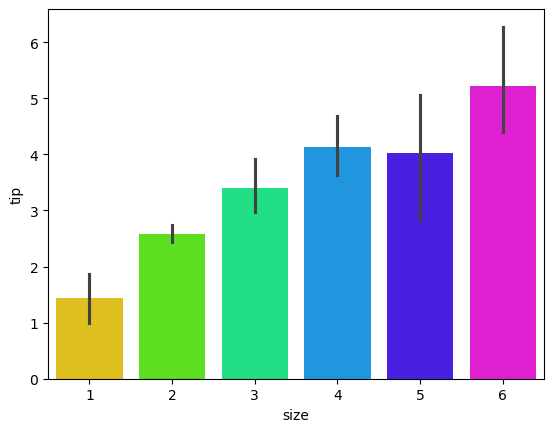

In [ ]:
sns.barplot(x='size', y='tip', data=df, palette='hsv')

In [88]:
px.bar(data_frame=df, x='size',y='total_bill', color='time')

# countplot
- 범주형 변수의 빈도수를 표현하는 차트 > 수치형은x

<Axes: xlabel='day', ylabel='count'>

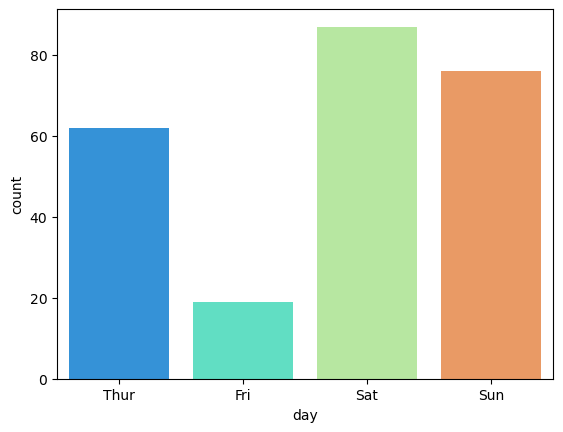

In [69]:
sns.countplot(x=df['day'], palette='rainbow')

<Axes: xlabel='day', ylabel='tip'>

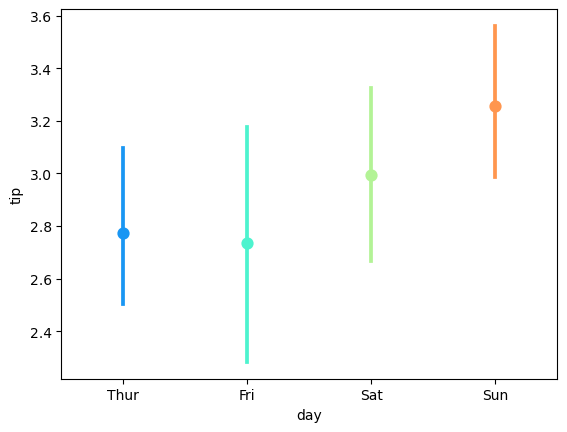

In [68]:
sns.pointplot(x='day',y='tip', data=df, palette='rainbow')

# histplot
수치형 변수들의 분포 

<Axes: xlabel='total_bill', ylabel='Count'>

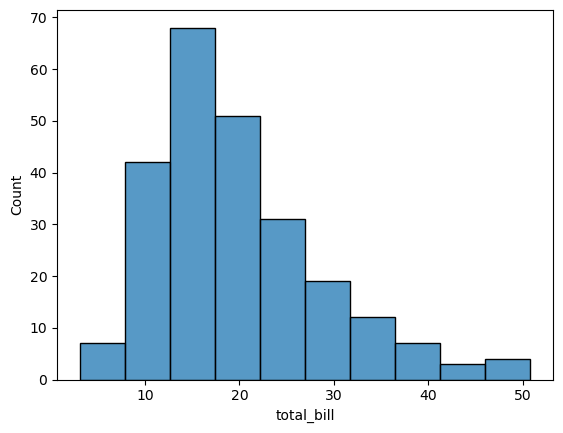

In [75]:
sns.histplot(x='total_bill' ,data=df, bins=50, binwidth=5)

<Axes: xlabel='total_bill', ylabel='Count'>

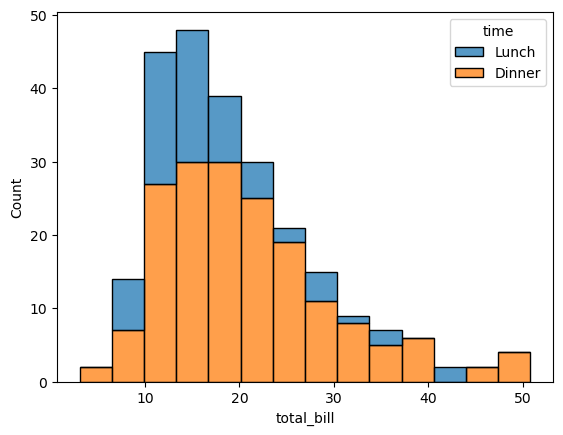

In [ ]:
# 다른 변수의 그룹별로 막대 나누기
sns.histplot(x='total_bill' ,data=df, hue='time',
             multiple='stack') # 값의 비중에 따라 안겹치게 보여줌 -> 전체 합계와 각가의 비중 보여줌

In [86]:
# plotly hilstogram
px.histogram(data_frame=df, x='total_bill', width=500, nbins=20, color='time', barmode='overlay')

# heatmap
- 데이터를 요약(합계, 평균...)한 결과를 색깔로 시각화
- 요약 -> 피봇 테이블(탐색) -> 인사이트 시각화 히트맵

In [92]:
# 요약
pivot_df = df.pivot_table('tip', 'day', 'size')
pivot_df

size,1,2,3,4,5,6
day,,,,,,
Thur,1.83,2.442500,2.692500,4.218000,5.000000,5.3
Fri,1.92,2.644375,3.000000,4.730000,NaN,NaN
Sat,1.00,2.517547,3.797778,4.123846,3.000000,NaN
Sun,NaN,2.816923,3.120667,4.087778,4.046667,5.0


<Axes: xlabel='size', ylabel='day'>

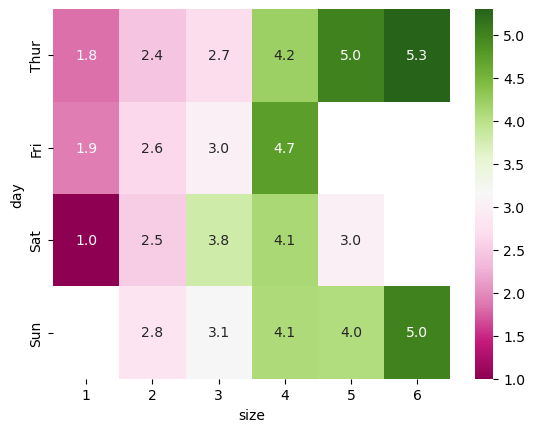

In [ ]:
# 시각화
sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap='PiYG')
# 널값 치라가 안되어있음

In [106]:
pivot_df.isnull()

size,1,2,3,4,5,6
day,,,,,,
Thur,False,False,False,False,False,False
Fri,False,False,False,False,True,True
Sat,False,False,False,False,False,True
Sun,True,False,False,False,False,False


In [107]:
pivot_df.fillna(0, inplace=True)

<Axes: xlabel='size', ylabel='day'>

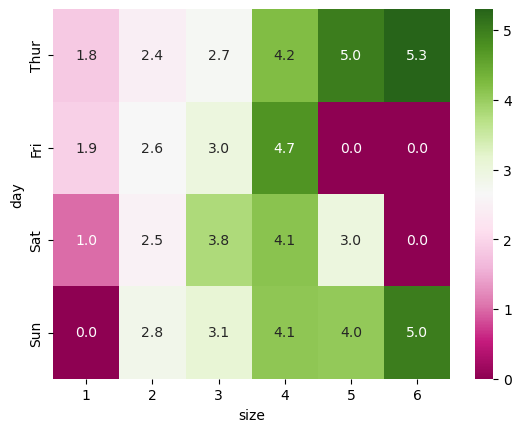

In [108]:
sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap='PiYG')

In [111]:
# plotly 버전
px.imshow(
    pivot_df, x= pivot_df.columns, y= pivot_df.index.astype(str),
    width = 400, height=400, text_auto='.2e'
)

# facetgrid
- 데이터를 범주형 변수에 따라 나눠서 각각 시각화


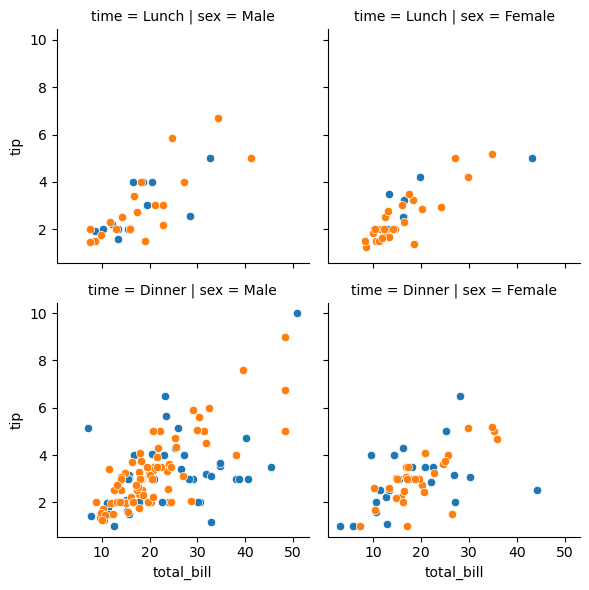

In [115]:
g =sns.FacetGrid(df, col='sex', row='time', hue='smoker',)
g.map(sns.scatterplot, 'total_bill', 'tip')

# parallel coordinates
- 평행좌표 플롯

In [120]:
iris_df = px.data.iris()

px.parallel_coordinates(
    iris_df,
    color = 'species_id',
    color_continuous_scale= px.colors.diverging.Tealrose )
